# Alzheimer's Disease Prediction
## End-to-End Data Science Portfolio Project

**Goal:** Build and evaluate a reproducible machine-learning workflow that predicts the binary `Diagnosis` label from demographic, lifestyle, medical, cognitive, and functional features.

### What this project demonstrates
- Data quality auditing and exploratory analysis
- Appropriate statistical inference and effect-size reporting
- Leakage-safe preprocessing with `Pipeline`
- Stratified train/test splitting
- Cross-validated model selection and hyperparameter tuning
- Evaluation with ROC-AUC, precision, recall, F1, and accuracy
- Model explainability with permutation importance
- Clear limitations and responsible interpretation

> **Important:** This is an educational machine-learning project using a public dataset. It is **not** a clinical diagnostic tool and must not be used for medical decision-making.

## 1. Imports and reproducibility

The notebook uses a single random seed for repeatability and avoids hidden preprocessing outside the model pipelines.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, classification_report
)
from sklearn.inspection import permutation_importance
import joblib

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

## 2. Load the data

The project uses a relative path so it runs on any machine after cloning/downloading the project folder.

In [2]:
DATA_PATH = Path('data/alzheimers_disease_data.csv')

if not DATA_PATH.exists():
    # Helpful fallback when the notebook is launched from outside the project folder.
    DATA_PATH = Path('/mnt/data/alzheimers_portfolio_rebuild/data/alzheimers_disease_data.csv')

df_raw = pd.read_csv(DATA_PATH)
print(f'Rows: {df_raw.shape[0]:,}')
print(f'Columns: {df_raw.shape[1]}')
df_raw.head()

Rows: 2,149
Columns: 35


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid


## 3. Data quality audit

Before modelling, check uniqueness, missingness, duplicates, target balance, and fields that should not be used as predictors.

In [3]:
audit = pd.Series({
    'rows': len(df_raw),
    'columns': df_raw.shape[1],
    'duplicate_rows': int(df_raw.duplicated().sum()),
    'missing_values': int(df_raw.isna().sum().sum()),
    'unique_patient_ids': int(df_raw['PatientID'].nunique()),
    'positive_diagnosis_rate': float(df_raw['Diagnosis'].mean())
})
audit

rows                       2149.000000
columns                      35.000000
duplicate_rows                0.000000
missing_values                0.000000
unique_patient_ids         2149.000000
positive_diagnosis_rate       0.353653
dtype: float64

In [4]:
print('DoctorInCharge unique values:', df_raw['DoctorInCharge'].unique())
print('\nDiagnosis distribution:')
print(df_raw['Diagnosis'].value_counts().rename(index={0: 'No diagnosis', 1: 'Diagnosis'}))

DoctorInCharge unique values: ['XXXConfid']

Diagnosis distribution:
Diagnosis
No diagnosis    1389
Diagnosis        760
Name: count, dtype: int64


### Modelling exclusions
- `PatientID` is an identifier, not a meaningful predictive feature.
- `DoctorInCharge` is constant/confidential metadata in this dataset and provides no useful predictive signal.

Both are removed before analysis/model training.

In [5]:
df = df_raw.drop(columns=['PatientID', 'DoctorInCharge']).copy()
TARGET = 'Diagnosis'
X_all = df.drop(columns=TARGET)
y_all = df[TARGET]
print(df.shape)

(2149, 33)


## 4. Exploratory data analysis

Rather than plotting every column, focus on variables with interpretable clinical/cognitive meaning and compare them with the target.

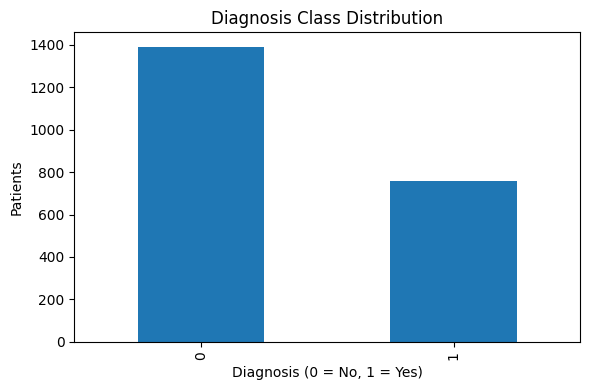

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
y_all.value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('Diagnosis Class Distribution')
ax.set_xlabel('Diagnosis (0 = No, 1 = Yes)')
ax.set_ylabel('Patients')
plt.tight_layout()
plt.show()

In [7]:
eda_features = ['Age', 'BMI', 'MMSE', 'FunctionalAssessment', 'ADL', 'SleepQuality']
summary_by_diagnosis = df.groupby(TARGET)[eda_features].agg(['mean', 'median']).round(2)
summary_by_diagnosis

Age           BMI          MMSE        FunctionalAssessment  \
            mean median   mean median   mean median                 mean   
Diagnosis                                                                  
0          74.95   75.0  27.52  27.56  16.27  17.15                 5.86   
1          74.84   75.0  27.91  28.00  11.99  11.57                 3.65   

                   ADL        SleepQuality         
          median  mean median         mean median  
Diagnosis                                          
0           6.24  5.71   6.14         7.12   7.24  
1           3.30  3.66   3.24         6.92   6.91

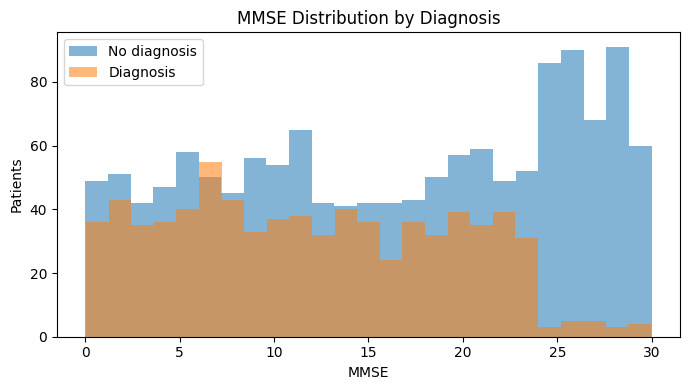

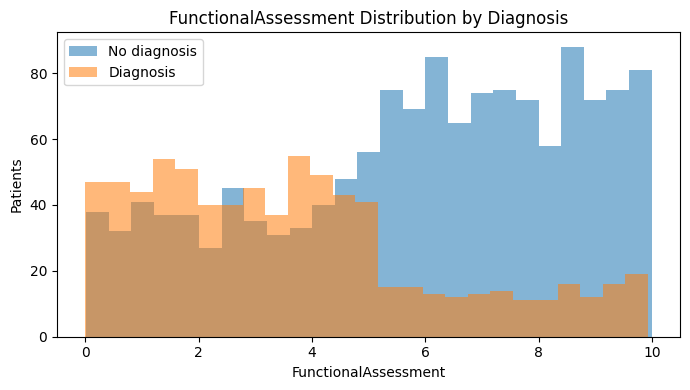

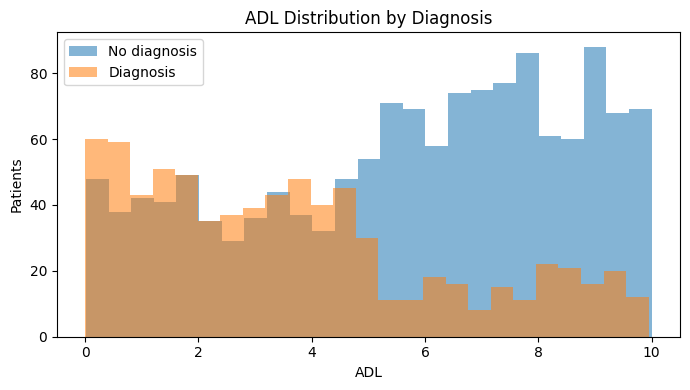

In [8]:
for feature in ['MMSE', 'FunctionalAssessment', 'ADL']:
    fig, ax = plt.subplots(figsize=(7, 4))
    for diagnosis, label in [(0, 'No diagnosis'), (1, 'Diagnosis')]:
        ax.hist(df.loc[df[TARGET] == diagnosis, feature], bins=25, alpha=0.55, label=label)
    ax.set_title(f'{feature} Distribution by Diagnosis')
    ax.set_xlabel(feature)
    ax.set_ylabel('Patients')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5. Statistical analysis — corrected and purposeful

This section keeps statistical inference tied to clear questions. We **do not assume the raw variables are normal simply because the sample is large**. The Central Limit Theorem concerns the sampling distribution of a statistic such as the mean, not the shape of the raw data.

### 5.1 Normality checks

Shapiro-Wilk is shown as a diagnostic. With a dataset this size it can detect small departures from normality, so p-values should be interpreted together with plots and robust test choices.

In [9]:
normality_features = ['Age', 'BMI', 'MMSE', 'FunctionalAssessment', 'ADL', 'SleepQuality']
normality_rows = []
for feature in normality_features:
    stat, p = stats.shapiro(df[feature])
    normality_rows.append({'feature': feature, 'W': stat, 'p_value': p, 'reject_normality_0.05': p < 0.05})

normality_results = pd.DataFrame(normality_rows)
normality_results

,feature,W,p_value,reject_normality_0.05
0,Age,0.952311,6.713639e-26,True
1,BMI,0.955787,5.050001e-25,True
2,MMSE,0.952533,7.609064e-26,True
3,FunctionalAssessment,0.955221,3.608048e-25,True
4,ADL,0.948223,7.180214e-27,True
5,SleepQuality,0.951192,3.589806e-26,True


### 5.2 BMI and depression — Welch's independent t-test

**Question:** Is mean BMI different between patients with and without depression?

Welch's t-test is used because it does not require equal population variances.

In [10]:
bmi_dep = df.loc[df['Depression'] == 1, 'BMI']
bmi_no_dep = df.loc[df['Depression'] == 0, 'BMI']

t_stat, p_value = stats.ttest_ind(bmi_dep, bmi_no_dep, equal_var=False)
mean_diff = bmi_dep.mean() - bmi_no_dep.mean()

pd.Series({
    'mean_BMI_depression': bmi_dep.mean(),
    'mean_BMI_no_depression': bmi_no_dep.mean(),
    'mean_difference': mean_diff,
    'welch_t': t_stat,
    'p_value': p_value
}).round(4)

mean_BMI_depression       27.4755
mean_BMI_no_depression    27.7009
mean_difference           -0.2254
welch_t                   -0.5853
p_value                    0.5585
dtype: float64

### 5.3 Depression and Alzheimer's diagnosis — Chi-square + Cramér's V

**Question:** Is depression associated with the binary diagnosis label?

For two categorical variables, a chi-square test is appropriate. Cramér's V adds an effect-size measure.

In [11]:
contingency = pd.crosstab(df['Depression'], df[TARGET])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
n = contingency.to_numpy().sum()
cramers_v = np.sqrt(chi2 / (n * min(contingency.shape[0]-1, contingency.shape[1]-1)))

print(contingency)
pd.Series({'chi2': chi2, 'dof': dof, 'p_value': p_chi, 'cramers_v': cramers_v}).round(4)

Diagnosis      0    1
Depression           
0           1108  610
1            281  150


chi2         0.0470
dof          1.0000
p_value      0.8283
cramers_v    0.0047
dtype: float64

### 5.4 Sleep quality and diagnosis — point-biserial correlation

**Question:** Is continuous sleep quality linearly associated with a binary diagnosis label?

In [12]:
r_pb, p_pb = stats.pointbiserialr(df[TARGET], df['SleepQuality'])
pd.Series({'point_biserial_r': r_pb, 'p_value': p_pb}).round(4)

point_biserial_r   -0.0565
p_value             0.0087
dtype: float64

## 6. Leakage-safe train/test split

The holdout test set is created **before any model fitting or scaling**. Model selection happens only on the training portion via stratified cross-validation.

In [13]:
X = df.drop(columns=TARGET)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

print('Training shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Training positive rate:', round(y_train.mean(), 4))
print('Test positive rate:', round(y_test.mean(), 4))

Training shape: (1611, 32)
Test shape: (538, 32)
Training positive rate: 0.3538
Test positive rate: 0.3532


## 7. Baseline

A majority-class dummy model establishes the minimum benchmark. A useful classifier should beat this baseline on discrimination metrics such as ROC-AUC and on class-specific metrics such as recall/F1.

In [14]:
dummy = DummyClassifier(strategy='prior', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_prob = dummy.predict_proba(X_test)[:, 1]

pd.Series({
    'accuracy': accuracy_score(y_test, dummy_pred),
    'roc_auc': roc_auc_score(y_test, dummy_prob)
}).round(4)

accuracy    0.6468
roc_auc     0.5000
dtype: float64

## 8. Cross-validated model selection

We compare five common classification algorithms. Scaling is placed **inside** the pipeline for algorithms that depend on feature scale. Hyperparameters are tuned only on the training data.

**Primary model-selection metric:** ROC-AUC. This is more informative than accuracy alone when class proportions are unequal.

In [15]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

model_specs = {
    'Logistic Regression': (
        Pipeline([
            ('scale', StandardScaler()),
            ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
        ]),
        {'model__C': [0.1, 1]}
    ),
    'KNN': (
        Pipeline([
            ('scale', StandardScaler()),
            ('model', KNeighborsClassifier())
        ]),
        {
            'model__n_neighbors': [9, 15],
            'model__weights': ['distance']
        }
    ),
    'Decision Tree': (
        Pipeline([
            ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
        ]),
        {
            'model__max_depth': [5, 7],
            'model__min_samples_leaf': [5, 10]
        }
    ),
    'Random Forest': (
        Pipeline([
            ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))
        ]),
        {
            'model__n_estimators': [100],
            'model__max_depth': [8, 12],
            'model__min_samples_leaf': [1, 3]
        }
    ),
    'SVM': (
        Pipeline([
            ('scale', StandardScaler()),
            ('model', SVC(random_state=RANDOM_STATE))
        ]),
        {
            'model__C': [0.5, 1],
            'model__kernel': ['linear']
        }
    )
}

In [16]:
searches = {}
comparison_rows = []

for name, (pipeline, param_grid) in model_specs.items():
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=cv,
        n_jobs=1,
        refit=True
    )
    search.fit(X_train, y_train)
    searches[name] = search
    comparison_rows.append({
        'model': name,
        'mean_cv_roc_auc': search.best_score_,
        'std_cv_roc_auc': search.cv_results_['std_test_score'][search.best_index_],
        'best_params': search.best_params_
    })

cv_results = pd.DataFrame(comparison_rows).sort_values('mean_cv_roc_auc', ascending=False).reset_index(drop=True)
cv_results

,model,mean_cv_roc_auc,std_cv_roc_auc,best_params
0,Random Forest,0.953466,0.006875,"{'model__max_depth': 12, 'model__min_samples_l..."
1,Decision Tree,0.942315,0.011384,"{'model__max_depth': 7, 'model__min_samples_le..."
2,SVM,0.904479,0.010448,"{'model__C': 0.5, 'model__kernel': 'linear'}"
3,Logistic Regression,0.903888,0.010265,{'model__C': 0.1}
4,KNN,0.826470,0.006308,"{'model__n_neighbors': 15, 'model__weights': '..."


In [17]:
Path('outputs').mkdir(exist_ok=True)
cv_results.to_csv('outputs/model_comparison.csv', index=False)

winner_name = cv_results.loc[0, 'model']
best_model = searches[winner_name].best_estimator_
print('Selected model based on training CV only:', winner_name)
print('Best CV ROC-AUC:', round(cv_results.loc[0, 'mean_cv_roc_auc'], 4))

Selected model based on training CV only: Random Forest
Best CV ROC-AUC: 0.9535


## 9. Final evaluation on the untouched test set

Only after choosing the winner from cross-validation do we evaluate the final model on the holdout test set.

In [18]:
y_pred = best_model.predict(X_test)

if hasattr(best_model, 'predict_proba'):
    y_score = best_model.predict_proba(X_test)[:, 1]
else:
    y_score = best_model.decision_function(X_test)

final_metrics = pd.Series({
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_score)
})

final_metrics.round(4)

accuracy     0.9387
precision    0.9486
recall       0.8737
f1           0.9096
roc_auc      0.9426
dtype: float64

In [19]:
print(classification_report(y_test, y_pred, target_names=['No diagnosis', 'Diagnosis']))

              precision    recall  f1-score   support

No diagnosis       0.93      0.97      0.95       348
   Diagnosis       0.95      0.87      0.91       190

    accuracy                           0.94       538
   macro avg       0.94      0.92      0.93       538
weighted avg       0.94      0.94      0.94       538



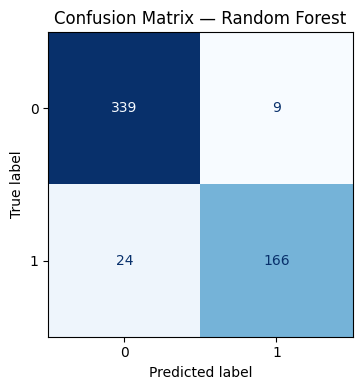

In [20]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {winner_name}')
plt.tight_layout()
plt.show()

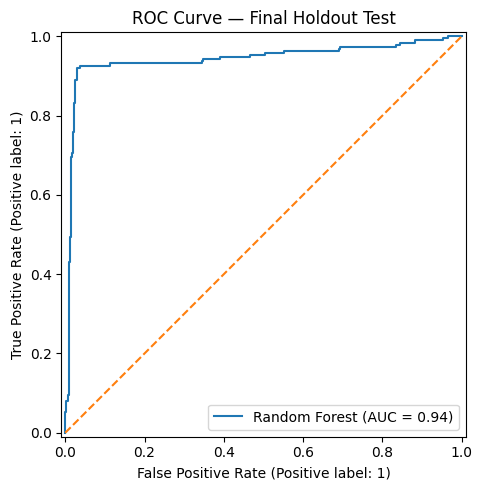

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_score, ax=ax, name=winner_name)
ax.plot([0, 1], [0, 1], linestyle='--')
ax.set_title('ROC Curve — Final Holdout Test')
plt.tight_layout()
plt.show()

## 10. Explainability — permutation importance

Permutation importance measures how much holdout ROC-AUC falls when each feature is shuffled. It is model-agnostic and is computed **after** model selection.

In [22]:
perm = permutation_importance(
    best_model, X_test, y_test,
    scoring='roc_auc',
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1
)

importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

top_importance = importance_df.head(12)
top_importance

,feature,importance_mean,importance_std
23,FunctionalAssessment,0.149870,0.004405
26,ADL,0.128884,0.016911
22,MMSE,0.084912,0.004667
24,MemoryComplaints,0.067311,0.008378
25,BehavioralProblems,0.050953,0.005723
20,CholesterolHDL,0.001455,0.000903
19,CholesterolLDL,0.001295,0.000705
0,Age,0.001098,0.000740
2,Ethnicity,0.000665,0.000291
11,CardiovascularDisease,0.000581,0.000434


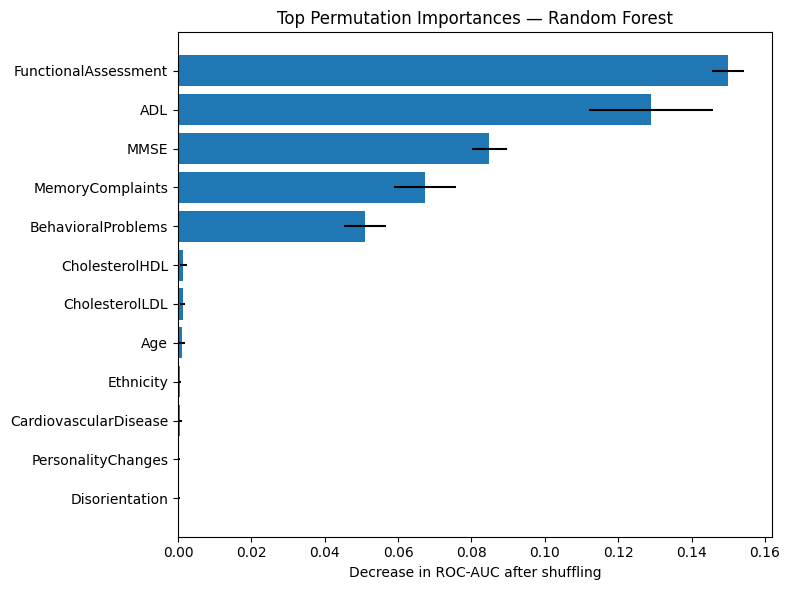

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_df = top_importance.sort_values('importance_mean')
ax.barh(plot_df['feature'], plot_df['importance_mean'], xerr=plot_df['importance_std'])
ax.set_title(f'Top Permutation Importances — {winner_name}')
ax.set_xlabel('Decrease in ROC-AUC after shuffling')
plt.tight_layout()
plt.show()

## 11. Save the fitted pipeline and results

Saving the entire fitted pipeline preserves every modelling step required for inference.

In [24]:
joblib.dump(best_model, 'outputs/best_model_pipeline.joblib')
final_metrics.rename('value').to_csv('outputs/final_test_metrics.csv')
importance_df.to_csv('outputs/permutation_importance.csv', index=False)
print('Saved model and result files to outputs/.')

Saved model and result files to outputs/.


## 12. Final interpretation

The final model should be discussed using **multiple metrics**, not accuracy alone. In this dataset, the cross-validation stage determines the winning algorithm, while the untouched holdout set estimates how that selected model generalizes to unseen records.

Key interpretation points:
1. **ROC-AUC** measures ranking/discrimination across thresholds.
2. **Recall** is especially important when missed positive cases carry a meaningful cost.
3. **Precision** describes how many positive predictions are correct.
4. **F1** balances precision and recall.
5. Permutation importance identifies the features most useful to this fitted model, but **does not establish causality**.

## 13. Limitations and responsible use

- This is a public educational dataset and the notebook does not establish clinical validity.
- Observational associations and feature importance do not imply causal relationships.
- The dataset represents a fixed sample; external validation on independent populations would be necessary before considering real-world use.
- Model performance can vary under demographic, measurement, or healthcare-system shifts.
- Clinical deployment would require calibration, subgroup/fairness analysis, prospective validation, governance, privacy review, and clinician oversight.
- The model is a portfolio demonstration, **not a diagnostic device**.

### Possible next steps
- Add probability calibration and calibration curves.
- Evaluate subgroup performance across age, gender, and ethnicity.
- Add SHAP explanations if a deployment/explainability layer is desired.
- Wrap the saved pipeline in a small API or Streamlit app as a separate engineering extension.

## Portfolio takeaway

This project demonstrates a complete data-science workflow: auditing data, asking focused statistical questions, preventing leakage, comparing models through cross-validation, evaluating an untouched holdout set, explaining predictions, and stating limitations clearly.